# Train the process surrogate

Train a differentiable PyTorch model to predict quality and energy load from the five disturbances and five manipulated variables. Run this notebook from `notebooks/` after `01_generate_data.ipynb`. The chronological 70/15/15 split is made **before** fitting scalers; the test partition is evaluated only after training and early stopping.

### Why a static surrogate?

A 10-input, 2-output network predicts quality and energy from the *current* disturbances and controls. The source process contains lag, so good test-set predictive accuracy does not guarantee correct off-policy or closed-loop behavior. The workflow is: configure → split → fit scalers → train → restore best weights → test → save diagnostics.

In [1]:
from copy import deepcopy
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cpu")
DATA_PATH = Path("../data/synthetic_process_data.csv")
MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../results")
INPUT_COLUMNS = [
    "d1_feed_grade", "d2_hardness", "d3_moisture", "d4_impurity", "d5_ambient",
    "u1_feed_rate", "u2_water_rate", "u3_reagent_rate", "u4_speed", "u5_temperature_setpoint",
]
OUTPUT_COLUMNS = ["y1_quality", "y2_energy_load"]
HIDDEN_SIZES = (32, 32, 16)
BATCH_SIZE = 256
MAX_EPOCHS = 150
PATIENCE = 18
MIN_DELTA = 1e-5


## Split in time before fitting scalers

Rows `0–5599` train the network, `5600–6799` select the best epoch, and `6800–7999` provide a held-out test. Random splitting would place autocorrelated neighbors in different partitions. `StandardScaler` is fitted to *training inputs and outputs only*; validation and test values use those same fitted statistics. Training on standardized outputs balances both channels, while reported MAE and RMSE are inverse-transformed into output units.

In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Generate the data with 01_generate_data.ipynb first: {DATA_PATH.resolve()}")
data = pd.read_csv(DATA_PATH)
required = INPUT_COLUMNS + OUTPUT_COLUMNS
missing = set(required) - set(data.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")
if len(data) != 8000 or not np.isfinite(data[required].to_numpy(dtype=float)).all():
    raise ValueError("Expected 8,000 finite, sequential observations")

train_end = int(0.70 * len(data))
val_end = int(0.85 * len(data))
partitions = {
    "train": data.iloc[:train_end],
    "validation": data.iloc[train_end:val_end],
    "test": data.iloc[val_end:],
}
input_scaler = StandardScaler().fit(partitions["train"][INPUT_COLUMNS])
output_scaler = StandardScaler().fit(partitions["train"][OUTPUT_COLUMNS])
arrays = {
    name: (
        input_scaler.transform(frame[INPUT_COLUMNS]).astype(np.float32),
        output_scaler.transform(frame[OUTPUT_COLUMNS]).astype(np.float32),
    )
    for name, frame in partitions.items()
}
print({name: len(frame) for name, frame in partitions.items()})


{'train': 5600, 'validation': 1200, 'test': 1200}


## Train the smooth 10–32–32–16–2 network

Three hidden layers with `SiLU` activations preserve a differentiable path from setpoints to outputs. AdamW optimizes minibatch mean squared error over both scaled outputs; shuffling applies only to the training loader. Gradient clipping limits large updates and `ReduceLROnPlateau` reduces the learning rate when validation stalls.

At each epoch record average training loss and validation loss. Save the best validation weights, stop after 18 unimproved epochs and restore those weights before evaluating the test interval. Fixed seeds and CPU execution support reproducibility.

In [3]:
class ProcessModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 32), nn.SiLU(),
            nn.Linear(32, 32), nn.SiLU(),
            nn.Linear(32, 16), nn.SiLU(),
            nn.Linear(16, 2),
        )

    def forward(self, inputs):
        return self.network(inputs)


model = ProcessModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=6)
loss_fn = nn.MSELoss()
train_x, train_y = (torch.from_numpy(a).to(DEVICE) for a in arrays["train"])
val_x, val_y = (torch.from_numpy(a).to(DEVICE) for a in arrays["validation"])
train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE,
                          shuffle=True, generator=torch.Generator().manual_seed(SEED))

history = {"train_loss": [], "validation_loss": [], "learning_rate": []}
best_loss = float("inf")
best_state = None
stale_epochs = 0
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for features, targets in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(features), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(features)
    train_loss = total_loss / len(train_x)
    model.eval()
    with torch.no_grad():
        validation_loss = loss_fn(model(val_x), val_y).item()
    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["learning_rate"].append(optimizer.param_groups[0]["lr"])
    scheduler.step(validation_loss)
    if validation_loss < best_loss - MIN_DELTA:
        best_loss = validation_loss
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            break
model.load_state_dict(best_state)
model.eval()
print(f"Trained {epoch} epochs; best epoch {best_epoch}, validation scaled MSE {best_loss:.6f}")


Trained 38 epochs; best epoch 20, validation scaled MSE 0.211924


## Evaluate and persist the model contract

For each chronological split, calculate R² (variance explained), MAE (mean absolute error) and RMSE (larger errors weigh more) separately for each physical-unit output. Scaled MSE describes the combined training loss. The test partition is evaluated only after validation has selected the epoch.

The checkpoint stores the best model's `state_dict`, feature order, output order and architecture. The two train-fitted scaler pickles must be loaded with that same feature order downstream, and only from a trusted local source.

In [4]:
predictions = {}
metrics = []
for split, (features, scaled_targets) in arrays.items():
    with torch.no_grad():
        scaled_prediction = model(torch.from_numpy(features).to(DEVICE)).cpu().numpy()
    scaled_loss = mean_squared_error(scaled_targets, scaled_prediction)
    actual = partitions[split][OUTPUT_COLUMNS].to_numpy()
    predicted = output_scaler.inverse_transform(scaled_prediction)
    predictions[split] = predicted
    for index, output in enumerate(OUTPUT_COLUMNS):
        metrics.append({
            "split": split, "output": output, "scaled_mse_loss": scaled_loss,
            "r2": r2_score(actual[:, index], predicted[:, index]),
            "mae": mean_absolute_error(actual[:, index], predicted[:, index]),
            "rmse": np.sqrt(mean_squared_error(actual[:, index], predicted[:, index])),
        })
metrics_df = pd.DataFrame(metrics)
display(metrics_df)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "input_columns": INPUT_COLUMNS,
    "output_columns": OUTPUT_COLUMNS,
    "hidden_sizes": HIDDEN_SIZES,
    "best_epoch": best_epoch,
}, MODEL_DIR / "process_model.pt")
with (MODEL_DIR / "input_scaler.pkl").open("wb") as file:
    pickle.dump(input_scaler, file)
with (MODEL_DIR / "output_scaler.pkl").open("wb") as file:
    pickle.dump(output_scaler, file)
metrics_df.to_csv(RESULTS_DIR / "training_metrics.csv", index=False)
print(f"Saved model and scalers to {MODEL_DIR.resolve()}; metrics to {RESULTS_DIR.resolve()}")


,split,output,scaled_mse_loss,r2,mae,rmse
0,train,y1_quality,0.139672,0.882574,0.450283,0.572006
1,train,y2_energy_load,0.139672,0.838082,0.463183,0.591110
2,validation,y1_quality,0.211924,0.852428,0.609640,0.755351
3,validation,y2_energy_load,0.211924,0.706149,0.561603,0.687579
4,test,y1_quality,0.189590,0.815006,0.542818,0.672968
5,test,y2_energy_load,0.189590,0.670550,0.534329,0.683743


Saved model and scalers to C:\Users\jaco238653\OneDrive - Hatch LTD\Documents\Python\NN_Optimization\neural-network-inverse-optimization\models; metrics to C:\Users\jaco238653\OneDrive - Hatch LTD\Documents\Python\NN_Optimization\neural-network-inverse-optimization\results


## Diagnostics on the held-out test interval

Parity and residual plots use unscaled values. Residual means actual minus predicted; trends can reveal dynamic lag not captured by this static surrogate.

### Watch learning and early stopping

Plot scaled training and validation losses against epoch and mark the best saved epoch. A growing gap can indicate poor generalization; reaching low training loss alone is insufficient evidence of useful control predictions.

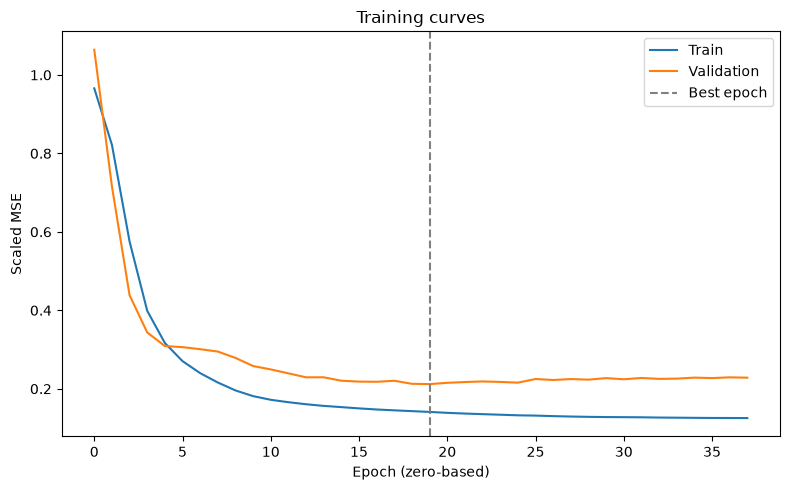

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["train_loss"], label="Train")
ax.plot(history["validation_loss"], label="Validation")
ax.axvline(best_epoch - 1, color="gray", linestyle="--", label="Best epoch")
ax.set(xlabel="Epoch (zero-based)", ylabel="Scaled MSE", title="Training curves")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()


### Held-out parity plots

Each dot compares one test measurement with its model prediction; the diagonal is perfect agreement. Vertical distance from the diagonal is error in the output's physical units. Range-dependent scatter or offset can expose bias.

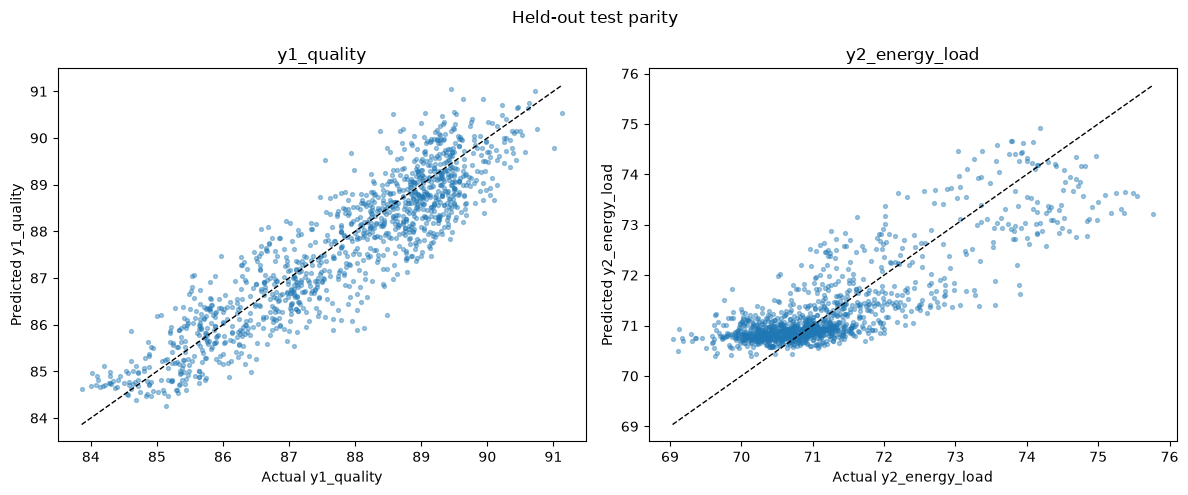

In [6]:
test_actual = partitions["test"][OUTPUT_COLUMNS].to_numpy()
test_predicted = predictions["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for index, (ax, output) in enumerate(zip(axes, OUTPUT_COLUMNS)):
    low = min(test_actual[:, index].min(), test_predicted[:, index].min())
    high = max(test_actual[:, index].max(), test_predicted[:, index].max())
    ax.scatter(test_actual[:, index], test_predicted[:, index], s=8, alpha=0.4)
    ax.plot([low, high], [low, high], "k--", linewidth=1)
    ax.set(xlabel=f"Actual {output}", ylabel=f"Predicted {output}", title=output)
fig.suptitle("Held-out test parity")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "parity_plot.png", dpi=150)
plt.show()


### Residuals over predictions and time

Residual is `actual - predicted`: positive means the network underestimated the measurement. Residual-versus-prediction reveals nonlinear bias, while residual-versus-time can reveal missing process dynamics or operating-regime shifts. A static surrogate may have acceptable average accuracy yet fail when its recommended actions leave historical operating conditions.

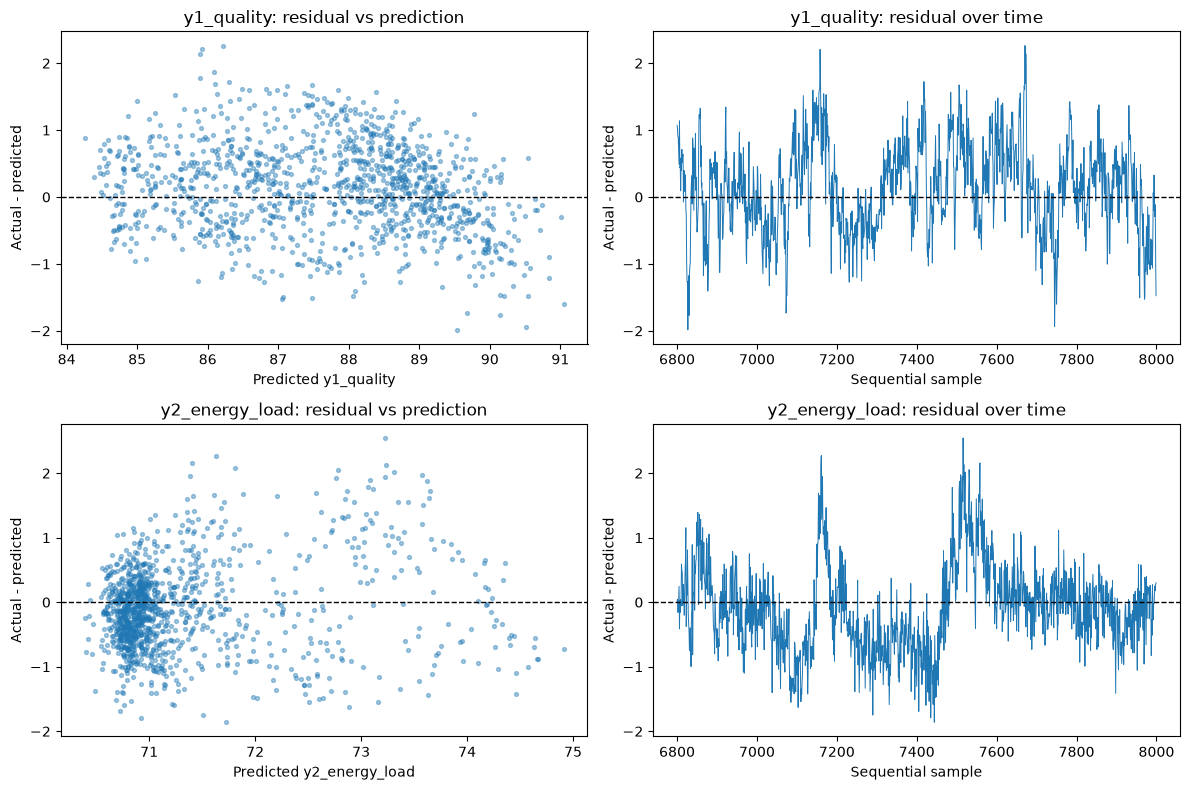

In [7]:
residuals = test_actual - test_predicted
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for index, output in enumerate(OUTPUT_COLUMNS):
    axes[index, 0].scatter(test_predicted[:, index], residuals[:, index], s=8, alpha=0.4)
    axes[index, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[index, 0].set(xlabel=f"Predicted {output}", ylabel="Actual - predicted", title=f"{output}: residual vs prediction")
    axes[index, 1].plot(partitions["test"].index, residuals[:, index], linewidth=0.7)
    axes[index, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[index, 1].set(xlabel="Sequential sample", ylabel="Actual - predicted", title=f"{output}: residual over time")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "residual_plots.png", dpi=150)
plt.show()
